## Анализ ошибок бейзлайна

Сравнение истинных и предсказанных ошибок

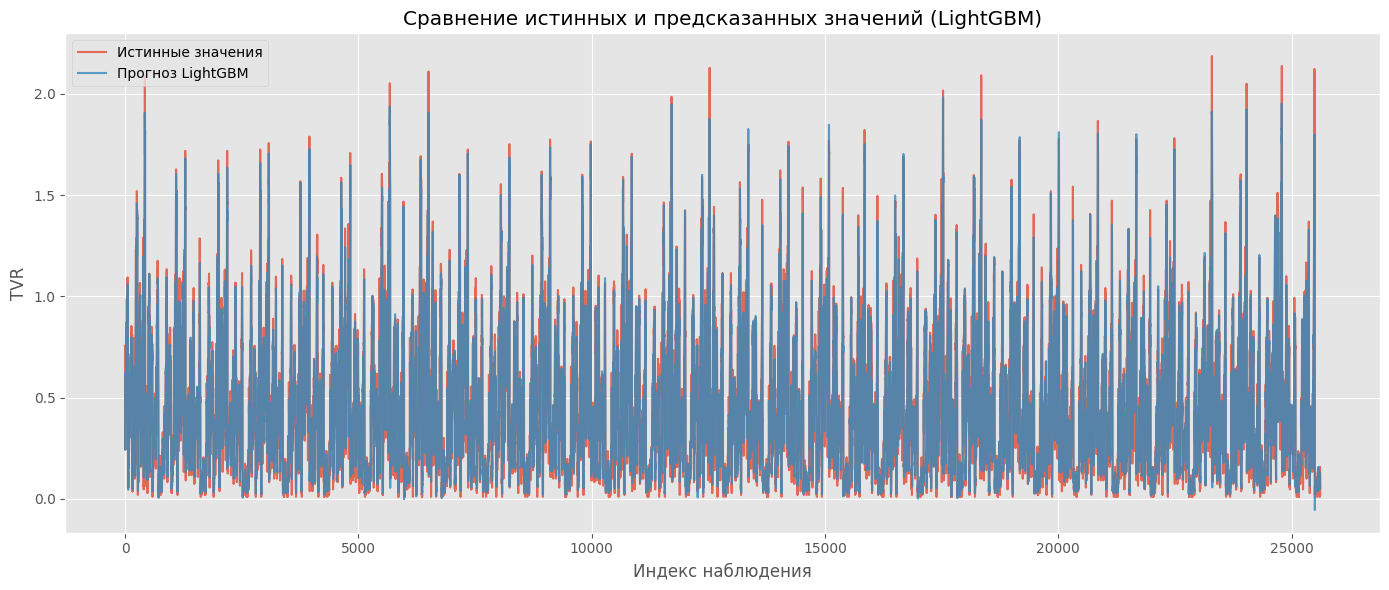

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Истинные значения', alpha=0.8)
plt.plot(lgb_preds, label='Прогноз LightGBM', alpha=0.8)
plt.title('Сравнение истинных и предсказанных значений (LightGBM)')
plt.xlabel('Индекс наблюдения')
plt.ylabel('TVR')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Метрики отдельно по каналам tvCompanyName

In [ ]:
def evaluate_by_channel(model, X_test, y_test, original_data, model_name='Model'):
    """
    Оценка модели по телеканалам

    Параметры:
    model - обученная модель
    X_test - тестовые признаки (без названия канала)
    y_test - тестовые значения целевой переменной
    original_data - исходный DataFrame с названиями каналов
    model_name - название модели для отчета
    """
    # Создаем копию X_test и добавляем названия каналов из исходных данных
    X_test_with_channels = X_test.copy()
    X_test_with_channels['tvCompanyName'] = original_data.loc[X_test.index, 'tvCompanyName']

    results = []
    channels = X_test_with_channels['tvCompanyName'].unique()

    for channel in channels:
        mask = X_test_with_channels['tvCompanyName'] == channel
        X_ch = X_test_with_channels[mask].drop('tvCompanyName', axis=1)  # Удаляем столбец с каналом перед предсказанием
        y_ch = y_test[mask]

        if len(X_ch) == 0:
            continue

        y_pred = model.predict(X_ch)

        results.append({
            'Channel': channel,
            'R2': r2_score(y_ch, y_pred),
            'MAPE': mean_absolute_percentage_error(y_ch, y_pred),
            'Count': len(y_ch),
            'Model': model_name
        })

    return pd.DataFrame(results).sort_values('MAPE')

#
lgb_by_channel = evaluate_by_channel(
    lgb_model,
    X_test,
    y_test,
    original_data=data,  # Исходный DataFrame с каналами
    model_name='LightGBM'
)

# Вывод результатов
print(lgb_by_channel.head(10))

      Channel        R2      MAPE  Count     Model
5      РЕН ТВ  0.867101  0.097506   1888  LightGBM
0     5 канал  0.938874  0.108003   1711  LightGBM
11        ТНТ  0.941777  0.137711   1896  LightGBM
3         НТВ  0.920589  0.137951   1772  LightGBM
9    ТВ Центр  0.901644  0.146042   1787  LightGBM
8         СТС  0.926739  0.167581   1764  LightGBM
6    Россия 1  0.900165  0.172757   1144  LightGBM
1      Звезда  0.810682  0.187719   2490  LightGBM
7   Россия 24  0.602124  0.215290   1568  LightGBM
10        ТВ3  0.799224  0.273715   2180  LightGBM


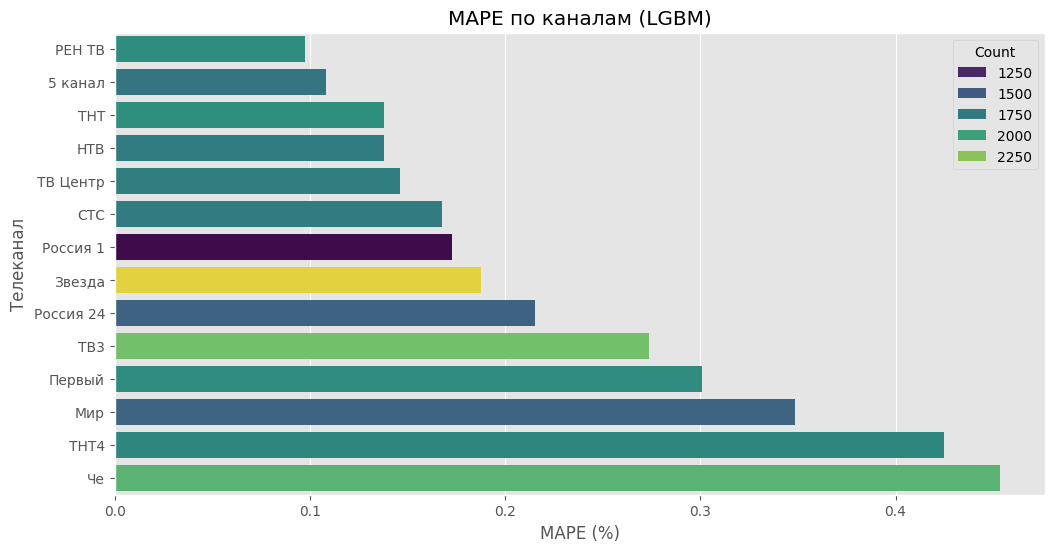

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x='MAPE',
    y='Channel',
    data=lgb_by_channel.sort_values('MAPE').head(20),
    hue='Count',
    palette='viridis'
)
plt.title('MAPE по каналам (LGBM)')
plt.xlabel('MAPE (%)')
plt.ylabel('Телеканал')
plt.show()

Анализ ошибок для всех моделей

In [ ]:
def analyze_model_errors(model, model_name, X_test, y_test, scaler=None, is_catboost=False):

    # Масштабируем, если нужно
    if not is_catboost and scaler:
        X_test = scaler.transform(X_test)

    # Предсказания
    preds = model.predict(X_test)
    errors = y_test - preds
    abs_errors = np.abs(errors)

    # Метрики
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)  # исправлено тут
    mape = mean_absolute_percentage_error(y_test, preds)

    print(f"\n{'═'*60}")
    print(f" Анализ ошибок: {model_name}")
    print(f"{'═'*60}")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape * 100:.2f}%")

    # Топ-10 ошибок
    error_df = pd.DataFrame({
        'True': y_test,
        'Predicted': preds,
        'Absolute_Error': abs_errors
    })
    top_errors = error_df.sort_values(by='Absolute_Error', ascending=False).head(10)
    print("\nТоп-10 грубых ошибок:")
    print(top_errors)

    # Визуализация
    plt.figure(figsize=(16, 10))
    plt.suptitle(f'{model_name} — Анализ ошибок', fontsize=16)

    # Истинные vs предсказанные
    plt.subplot(2, 2, 1)
    sns.scatterplot(x=y_test, y=preds, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Истинные значения')
    plt.ylabel('Предсказанные')
    plt.title('Истинные vs Предсказанные')

    # Гистограмма ошибок
    plt.subplot(2, 2, 2)
    sns.histplot(errors, kde=True, bins=30, color='purple')
    plt.title('Гистограмма ошибок')

    # Boxplot ошибок
    plt.subplot(2, 2, 3)
    sns.boxplot(x=errors, color='orange')
    plt.title('Boxplot ошибок')

    # Остатки vs Предсказанные
    plt.subplot(2, 2, 4)
    sns.scatterplot(x=preds, y=errors, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.title('Остатки vs Предсказания')
    plt.xlabel('Предсказанные значения')
    plt.ylabel('Остатки')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



════════════════════════════════════════════════════════════
 Анализ ошибок: Linear Regression
════════════════════════════════════════════════════════════
MAE:  0.1004
MSE:  0.0197
RMSE: 0.1402
MAPE: 74.86%

Топ-10 грубых ошибок:
             True  Predicted  Absolute_Error
1480009  0.028101   2.379943        2.351842
1460942  0.157858   1.937271        1.779413
1478553  0.235862   1.887796        1.651933
1472835  0.235862   1.880750        1.644888
1467820  0.181905   1.823450        1.641545
1460109  1.819375   3.420682        1.601307
1477802  1.939676   3.499354        1.559677
1469559  0.205387   1.722242        1.516856
1473658  0.189794   1.690681        1.500888
1475343  0.197621   1.697228        1.499607


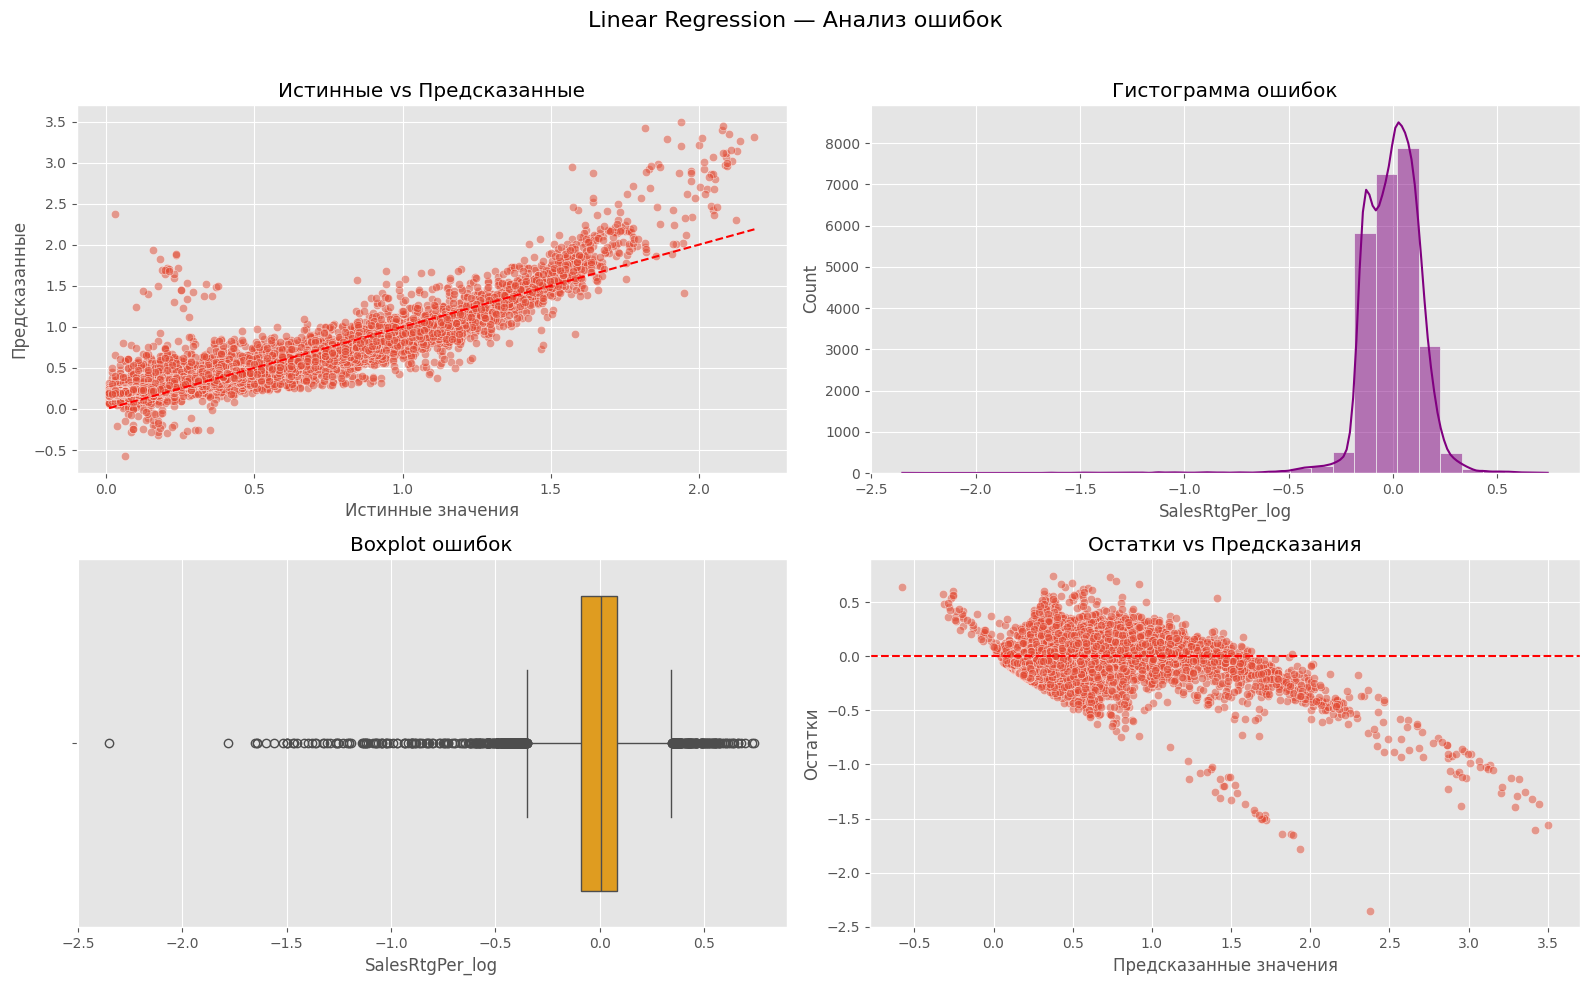


════════════════════════════════════════════════════════════
 Анализ ошибок: Random Forest
════════════════════════════════════════════════════════════
MAE:  0.3483
MSE:  0.1726
RMSE: 0.4154
MAPE: 86.85%

Топ-10 грубых ошибок:
             True  Predicted  Absolute_Error
1460105  1.949190   0.055582        1.893608
1477799  2.060450   0.436975        1.623475
1471974  1.580421   0.107956        1.472465
1477798  1.909172   0.456044        1.453128
1460074  1.468796   0.055080        1.413716
1466131  1.466606   0.068466        1.398140
1457320  1.725798   0.432623        1.293174
1479272  1.315469   0.061203        1.254267
1477769  1.473160   0.226825        1.246335
1454808  1.289646   0.073716        1.215929


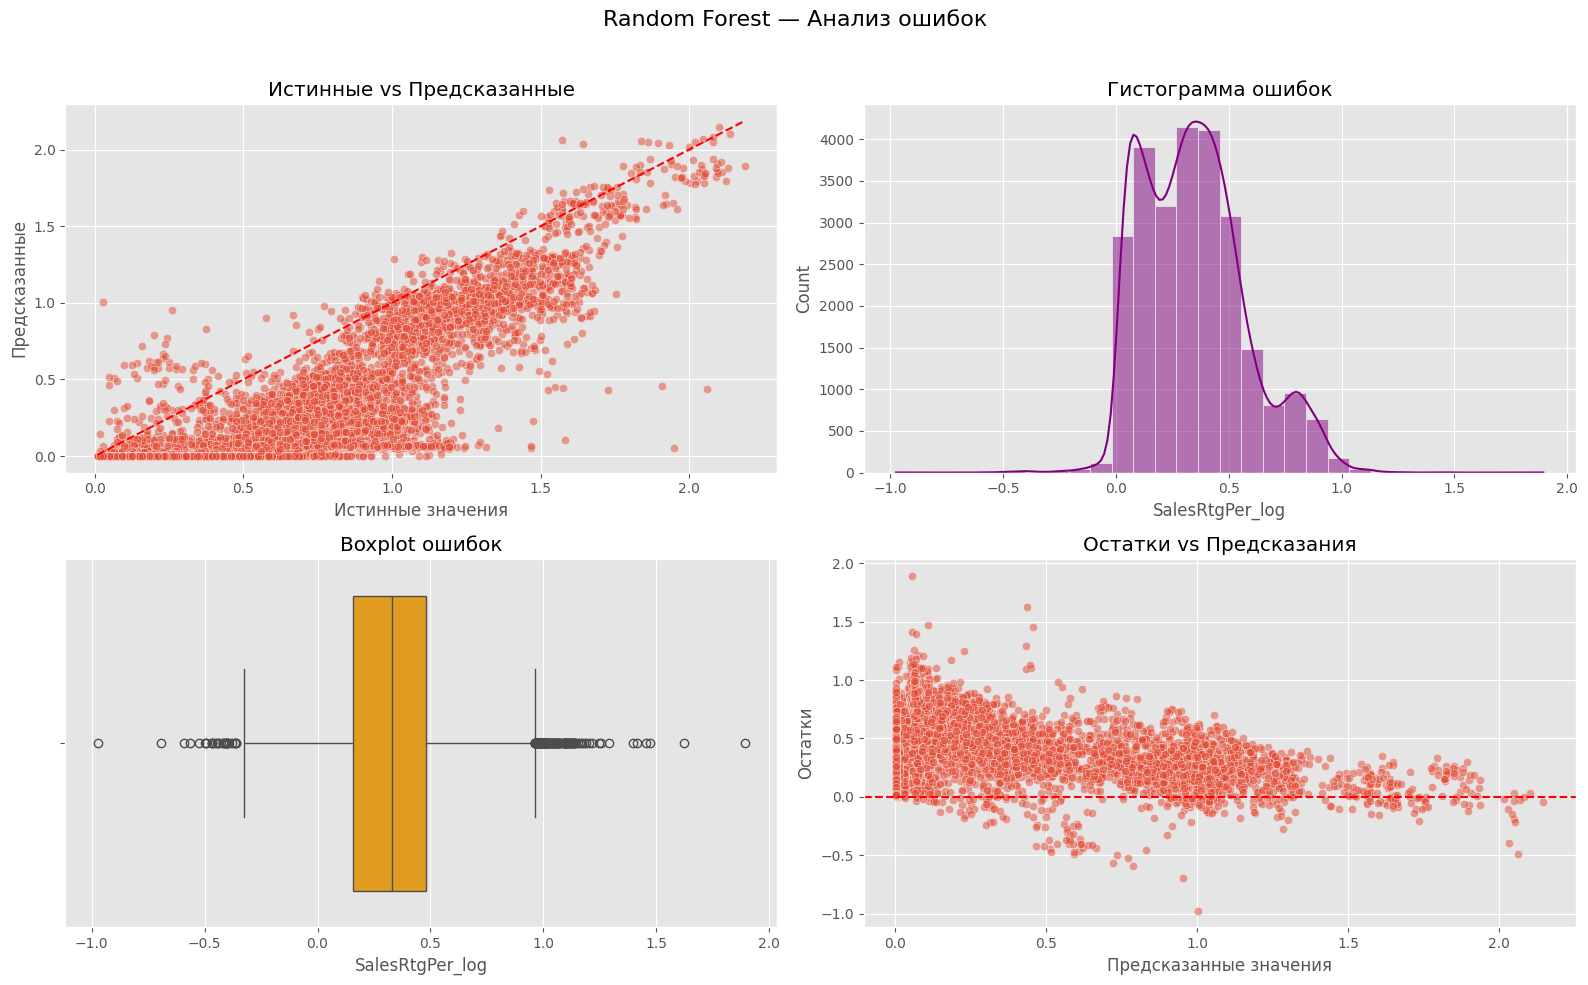


════════════════════════════════════════════════════════════
 Анализ ошибок: LightGBM
════════════════════════════════════════════════════════════
MAE:  0.3478
MSE:  0.1645
RMSE: 0.4056
MAPE: 80.10%

Топ-10 грубых ошибок:
             True  Predicted  Absolute_Error
1460105  1.949190   0.518113        1.431078
1471974  1.580421   0.159652        1.420769
1466131  1.466606   0.077191        1.389416
1477769  1.473160   0.097999        1.375161
1460074  1.468796   0.223743        1.245053
1460907  1.294864   0.051918        1.242946
1454808  1.289646   0.059041        1.230605
1459219  1.357895   0.153920        1.203974
1472802  1.173256   0.002016        1.171240
1478526  1.246889   0.095313        1.151575


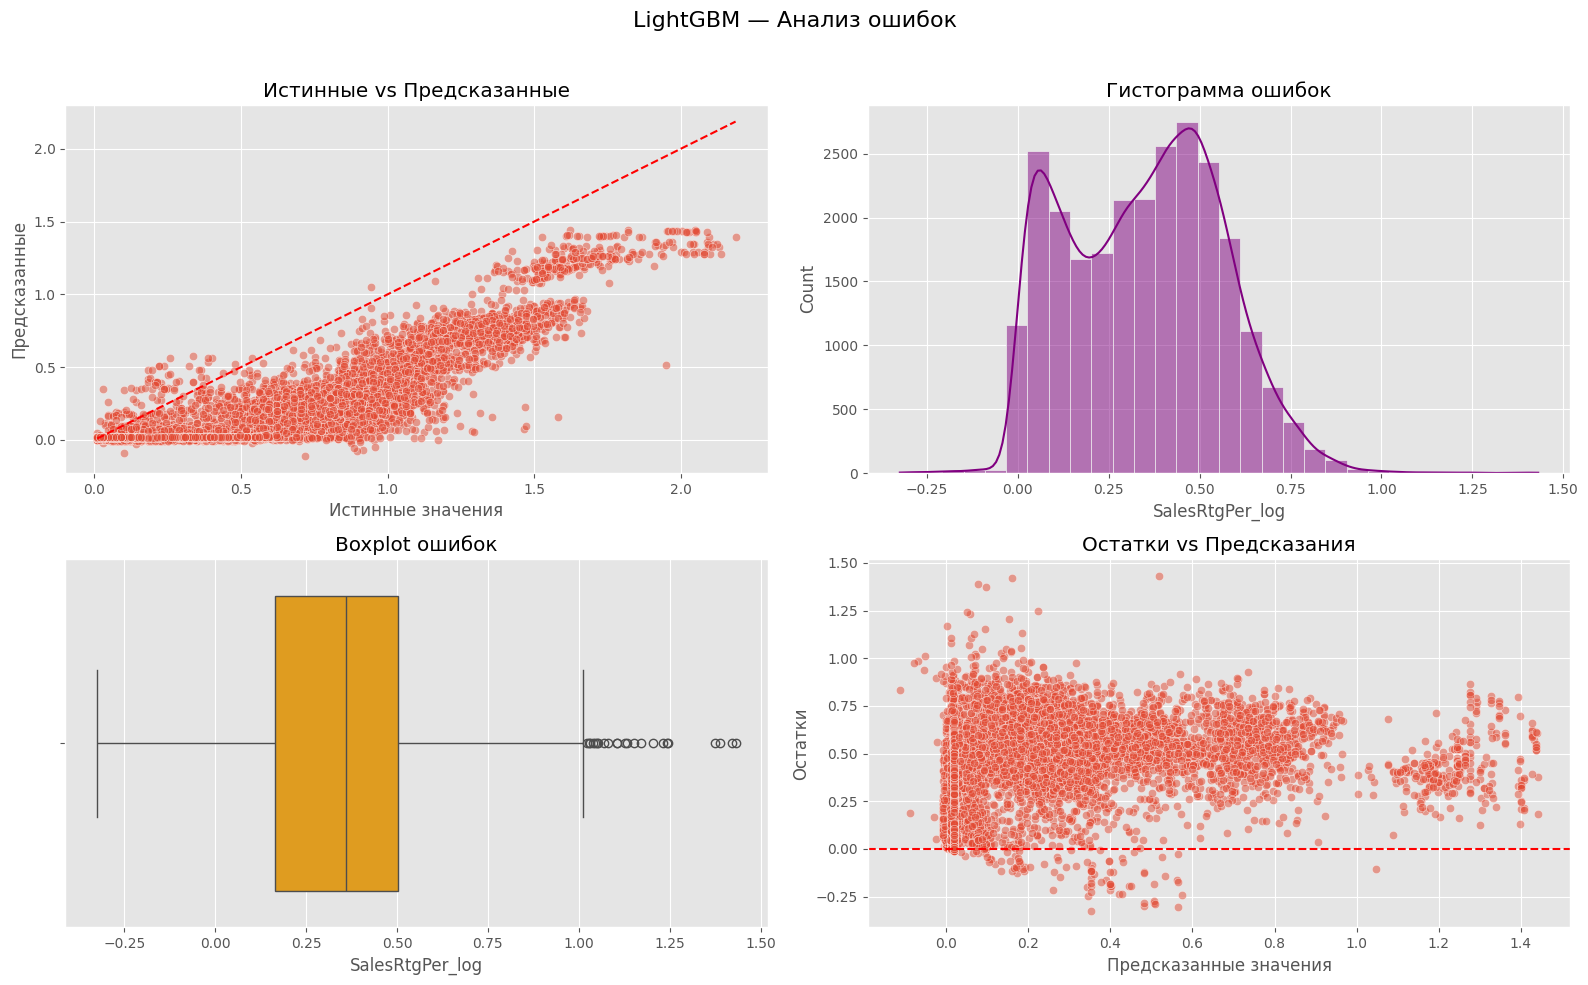


════════════════════════════════════════════════════════════
 Анализ ошибок: CatBoost
════════════════════════════════════════════════════════════
MAE:  0.0486
MSE:  0.0050
RMSE: 0.0708
MAPE: 21.21%

Топ-10 грубых ошибок:
             True  Predicted  Absolute_Error
1479827  1.115797   0.382616        0.733181
1457662  0.181905   0.910838        0.728933
1471977  0.082041   0.720889        0.638849
1459888  1.090580   0.472796        0.617784
1478376  0.220741   0.832296        0.611556
1475306  1.176190   0.583696        0.592494
1465274  0.149712   0.700619        0.550906
1471801  0.197621   0.737563        0.539943
1479272  1.315469   0.793529        0.521941
1479833  0.099393   0.619274        0.519882


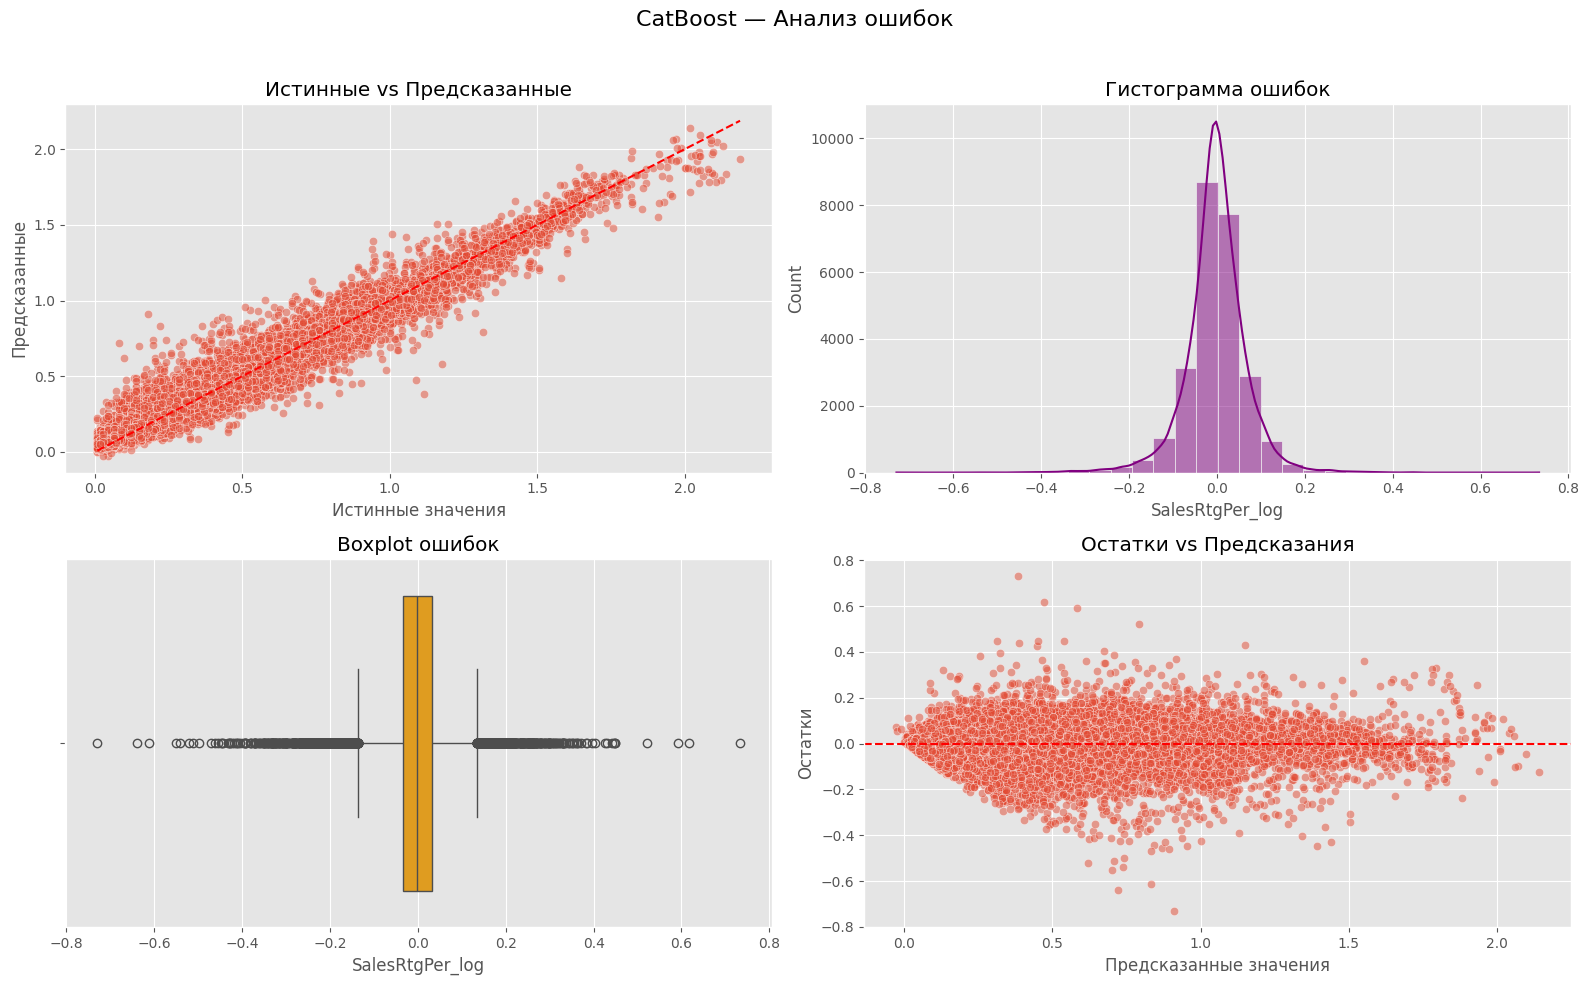

In [ ]:
# Анализ по всем моделям
analyze_model_errors(lr_model, 'Linear Regression', X_test, y_test, scaler)
analyze_model_errors(rf_model, 'Random Forest', X_test, y_test, scaler)
analyze_model_errors(lgb_model, 'LightGBM', X_test, y_test, scaler)
analyze_model_errors(cat_model, 'CatBoost', X_test, y_test, scaler, is_catboost=True)
